In [ ]:
# loads the dataset from kaggle to google colab

from google.colab import drive
drive.mount('/content/drive')

!mkdir ~/.kaggle
!cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download grassknoted/asl-alphabet
!kaggle datasets download danrasband/asl-alphabet-test

!unzip asl-alphabet.zip
!unzip asl-alphabet-test.zip

!rm asl-alphabet.zip
!rm asl-alphabet-test.zip

!rm -r sample_data A B C D E F G H I J K L M N O P Q R S T U V W X Y Z del space nothing
!rm -r asl_alphabet_test

!mv asl_alphabet_train/asl_alphabet_train/* asl_alphabet_train
!rm -r asl_alphabet_train/asl_alphabet_train

!mv asl-alphabet-test asl_alphabet_test

Streaming output truncated to the last 5000 lines.
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing766.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing767.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing768.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing769.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing77.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing770.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing771.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing772.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing773.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing774.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing775.jpg  
  inflating: asl_alphabet_train/asl_alphabet_train/nothing/nothing776.jpg  
  inflating: asl_alphabet_train/asl_al

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)), # resize to 224x224, size resnet18 is trained on
    transforms.RandomRotation(15), # randomly rotate images upto 15 degrees
    transforms.RandomHorizontalFlip(), # randomly flip the images horizontally
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # randomly shifts images and random scaling
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05), # apply brightest, contrast, saturation, and hue variations
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)), # apply gaussian blur to the images
    transforms.ToTensor(), # converts to tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # normalize dataset with mean and std from imagenet
])

# no data augmentation for test transform
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

batch_size = 1024 # high bactch size to maximize gpu ram

# load train dataset
train_dataset_path = 'asl_alphabet_train'
train_dataset = ImageFolder(train_dataset_path, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# load test dataset
val_dataset_path = 'asl_alphabet_test'
val_dataset = ImageFolder(val_dataset_path, transform=test_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

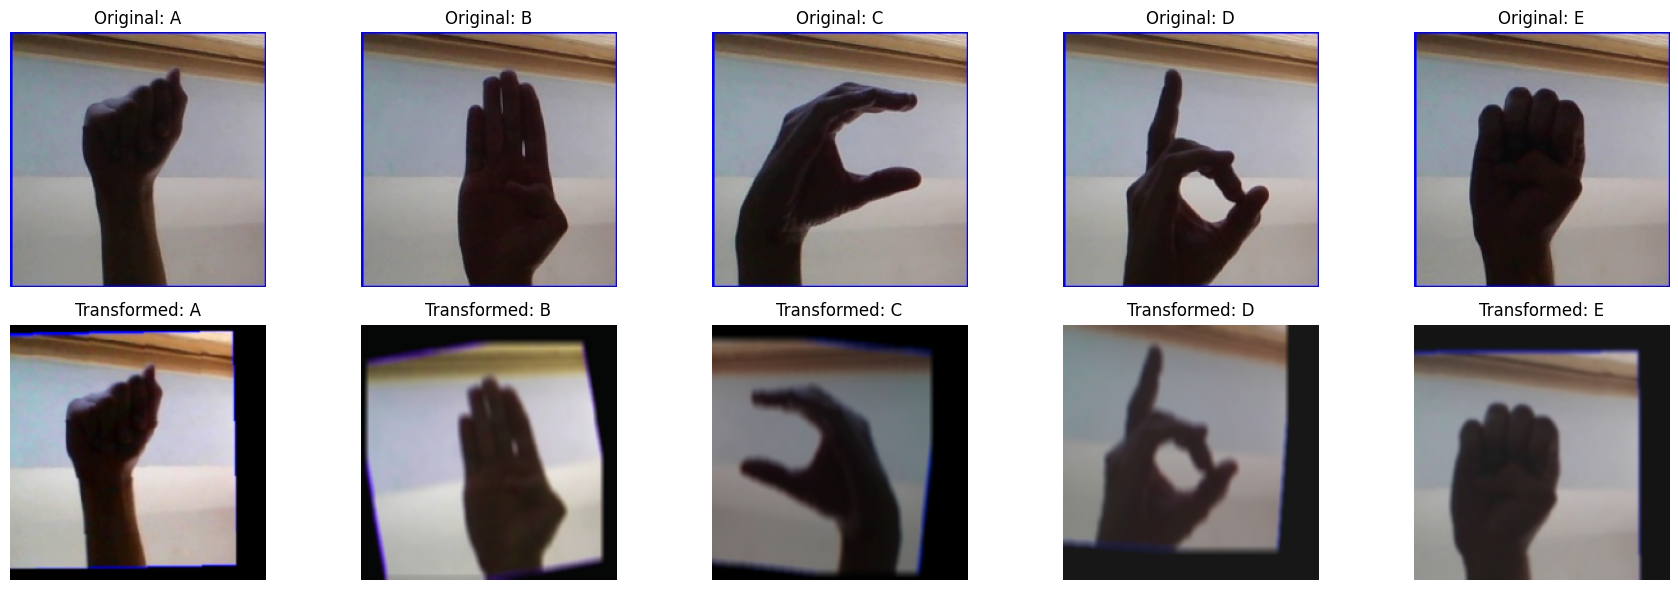

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# mean and std from imaget stats
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
class_names = train_dataset.classes

# get the indices of the first images of letters A - E
indices = [i*3000 for i in range(5)]

# 2x5 subplot to display 10 images
fig, axes = plt.subplots(2, 5, figsize=(18, 6))

# iterate through the indices
for col, idx in enumerate(indices):
    # plot original dataset
    # get the img_path and label of the image
    img_path, label = train_dataset.samples[idx]
    img = Image.open(img_path)
    axes[0, col].imshow(img) # display the image
    axes[0, col].set_title(f"Original: {class_names[label]}")
    axes[0, col].axis('off')

    # plot transformed dataset
    # get the tensor (transformation already applied)
    img_tensor, label = train_dataset[idx]
    # unormalize the image
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1) # ensures the pixel values are [0-1]
    axes[1, col].imshow(img_np)
    axes[1, col].set_title(f"Transformed: {class_names[label]}")
    axes[1, col].axis('off')

plt.tight_layout()
plt.show() # show the plot

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch
from torchvision.models import resnet18, ResNet18_Weights

num_classes = len(train_dataset.classes) # get num of classes
# load resnet18 model with pretrained weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
# modify the final layer to match the number of classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

# use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # move model to the device

# Use categorical cross-entropy loss function
# used for multiclass classfication
criterion = nn.CrossEntropyLoss()

lr = 0.001 # learning rate for the optimizer
# use adam optimizer for training
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
from tqdm import tqdm # for progres bar

# number of epochs, low because it reach high accuracy fast
num_epochs = 5

# to keep tracks of the losses and accuracy
# used for plotting later
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# to keep track of the best validation accuracy
best_accuracy = -1

# print dataset and device info
print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")
print(f"Class names: {train_dataset.classes}")
print(f"Starting training on {device}")
print('-' * 50)

for epoch in range(num_epochs):
  model.train() # set to training mode

  # to track training loss
  train_loss = 0.0
  # used for calculating train accuracy
  train_correct = 0
  train_total = 0

  # training loop with progress bar
  train_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Train]')
  for inputs, labels in train_bar:
    # move to device
    inputs = inputs.to(device)
    labels = labels.to(device)


    optimizer.zero_grad() # reset the gradients
    outputs = model(inputs) # forward pass
    loss = criterion(outputs, labels) # get loss
    loss.backward() # backpropagation
    optimizer.step() # update the weights

    train_loss += loss.item() * inputs.size(0) # add the loss
    _, predicted = outputs.max(1) # get predictions
    train_correct += predicted.eq(labels).sum().item() # add correct predictions
    train_total += labels.size(0) # add to total

    # print the current training loss and accuracy
    train_bar.set_postfix({
        'Loss': f'{loss.item():.4f}',
        'Acc': f'{100.*train_correct/train_total:.2f}%'
    })


  train_loss /= len(train_loader.dataset) # calc avg loss
  train_acc = 100.*train_correct/train_total # calc accuracy
  train_losses.append(train_loss) # add loss for the current epoch
  train_accuracies.append(train_acc) # add accuracy for the current epoch

  model.eval() # set to evaluation mode
  # to track validation loss
  val_loss = 0.0
  # used for calculating validation accuracy
  val_correct = 0
  val_total = 0

  # validation loop with progress bar
  val_bar = tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} [Val]')
  with torch.no_grad():
    for inputs, labels in val_bar:
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs) # forward pass
      loss = criterion(outputs, labels) # get the loss

      val_loss += loss.item() * inputs.size(0) # add the loss
      _, predicted = outputs.max(1) # get the predictions
      val_correct += predicted.eq(labels).sum().item() # add correct predictions
      val_total += labels.size(0) # add to total

      # print the current validation loss and accuracy
      val_bar.set_postfix({
          'Loss': f'{loss.item():.4f}',
          'Acc': f'{100.*val_correct/val_total:.2f}%'
      })

    val_loss /= len(val_loader.dataset) # calc avg validation loss
    val_acc = 100.*val_correct/val_total # calc accuracy

    # save model if it's has the best validation acc
    if val_acc > best_accuracy:
      best_accuracy = val_acc
      torch.save(model.state_dict(), 'Resnet18.pth') # save as 'Resnet18.pth'

    val_losses.append(val_loss) # add loss for the current epoch
    val_accuracies.append(val_acc) # add acc for the current epoch

    # print the final loss and accuracy of both training and validation
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    print('-' * 50)

Train dataset: 87000
Val dataset: 870
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Starting training on cuda
--------------------------------------------------


Epoch 1/5 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.91s/it, Loss=2.7195, Acc=54.25%]


Epoch 1/5
Train Loss: 0.1802 | Train Acc: 95.92%
Val Loss: 2.7195 | Val Acc: 54.25%
--------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.87s/it, Loss=3.1832, Acc=47.93%]


Epoch 2/5
Train Loss: 0.0108 | Train Acc: 99.71%
Val Loss: 3.1832 | Val Acc: 47.93%
--------------------------------------------------


...

Epoch 3/5
Train Loss: 0.0095 | Train Acc: 99.75%
Val Loss: 4.5241 | Val Acc: 44.48%
--------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.93s/it, Loss=4.2712, Acc=46.09%]


Epoch 4/5
Train Loss: 0.0084 | Train Acc: 99.75%
Val Loss: 4.2712 | Val Acc: 46.09%
--------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 1/1 [00:01<00:00,  1.90s/it, Loss=3.0940, Acc=48.85%]

Epoch 5/5
Train Loss: 0.0070 | Train Acc: 99.81%
Val Loss: 3.0940 | Val Acc: 48.85%
--------------------------------------------------


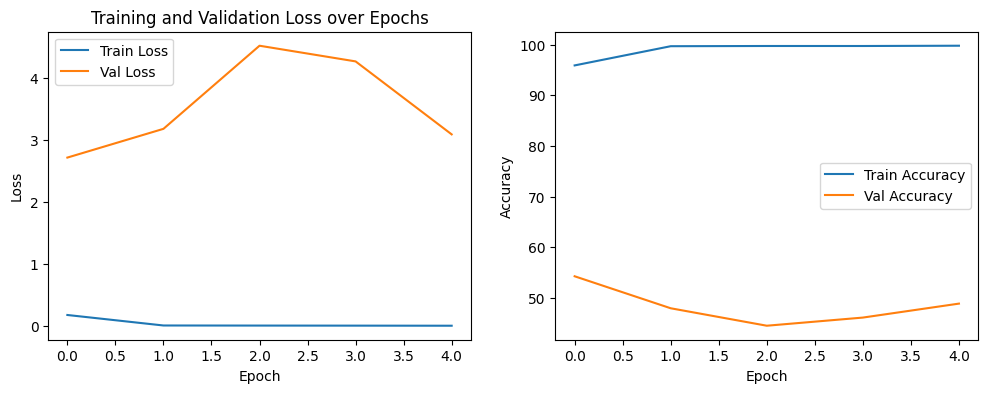

In [ ]:
plt.figure(figsize=(12, 4))

# plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()

# plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()

plt.show() # show the plot

<ipython-input-13-0ffc01d0bee3>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ResNet18.pth'))


Test Accuracy: 54.25%


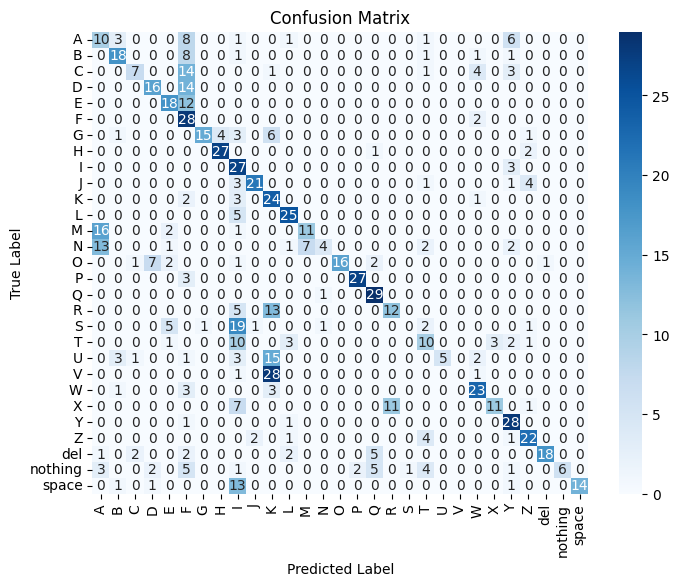

In [ ]:
import seaborn as sns # for heatmap
from sklearn.metrics import confusion_matrix # for computing the confusion matrix

# load resnet18 without the weights
model = resnet18(weights=None)
# modify final layer to have 29 classes
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load('Resnet18.pth')) # load the trained model weights
model = model.to(device) # move to device

# for calculatin acc
correct = 0
total = 0

# to keep track of the true label and predicted label
all_labels = []
all_preds = []

model.eval() # set to evaluation mode

with torch.no_grad():
  for inputs, labels in val_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = model(inputs) # forward pass
    _, predicted = outputs.max(1) # get the predictions

    correct += (predicted == labels).sum().item() # add correct predictions
    total += labels.size(0) # add to total

    # add true labels and prediction
    # move to cpu to create numpy array
    all_labels.extend(labels.cpu().numpy())
    all_preds.extend(predicted.cpu().numpy())

accuracy = 100 * correct / total # calc accuracy
print(f'Test Accuracy: {accuracy:.2f}%') # print accuracy

class_names = val_dataset.classes # get class names
cm = confusion_matrix(all_labels, all_preds) # calculate the confusion matix
# plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()